# 13 - NCMs mais comuns em supermercados e redes varejistas

**Pergunta:** quais c?digos NCM aparecem com maior frequ?ncia nos itens de notas fiscais emitidas por supermercados e grandes redes varejistas da base original?

A an?lise usa os Parquets mensais de `data/interim/items-notas-fiscais/`, que preservam os registros sem os filtros de modelagem. A base vem dos CSVs de notas, itens e eventos do Portal da Transpar?ncia (notebook 10). A identifica??o de estabelecimentos ? feita pelo nome do emitente e, quando dispon?vel, pelo CNPJ. Como raz?o social n?o comprova por si s? o ramo de atividade, os candidatos s?o inspecionados antes de fechar a lista inclu?da. Frequ?ncia significa quantidade de linhas de item, n?o quantidade vendida nem notas ?nicas.

In [20]:
from pathlib import Path
import re
import unicodedata

import pandas as pd
from IPython.display import display

# Configura??es da an?lise
# Localiza a raiz do projeto para que o notebook funcione mesmo quando
# o Jupyter Lab tiver outro diret?rio de trabalho.
DIRETORIO_NOTEBOOK = Path.cwd().resolve()
for DIRETORIO_CANDIDATO in (DIRETORIO_NOTEBOOK, *DIRETORIO_NOTEBOOK.parents):
    if (DIRETORIO_CANDIDATO / "data" / "interim" / "items-notas-fiscais").is_dir():
        RAIZ_PROJETO = DIRETORIO_CANDIDATO
        break
else:
    raise FileNotFoundError(
        "N?o encontrei a raiz do projeto. Abra o notebook dentro do reposit?rio "
        "ou ajuste RAIZ_PROJETO para o diret?rio que cont?m data/."
    )

INPUT_DIR = RAIZ_PROJETO / "data" / "interim" / "items-notas-fiscais"
PERIODS = ["2025-01", "2025-02", "2025-03", "2025-04"]
TOP_N = 15 # quantidade de emissores no ranking
TOP_N_NCMS_POR_EMISSOR = 30 # quantidade de NCMs em cada gr?fico

# Padr?es de descoberta de candidatos. A lista ? ampla de prop?sito;
# revise CANDIDATOS_EMITENTES antes de usar a contagem final.
PADROES_REDES = [
    r"CARREFOUR", r"ATACAD.AO", r"SENDAS DISTRIBUIDORA", r"ASSAI",
    r"P.AO DE A.C.UCAR", r"COMPANHIA BRASILEIRA DE DISTRIBUI.C.AO",
    r"WMS SUPERMERCADOS", r"BIG MAIS SUPERMERCADOS", r"CENCOSUD",
    r"SUPERMERC", r"HIPERMERC", r"MERCADO",
]

# Raz?es sociais inclu?das ap?s a revis?o explorat?ria; editar conforme
# a tabela de candidatos na pr?xima etapa. O match por nome ? intencional.
PADROES_INCLUSAO = [
    r"CARREFOUR", r"ATACAD.AO S\.A\.", r"SENDAS DISTRIBUIDORA",
    r"ASSAI ATACADISTA", r"WMS SUPERMERCADOS", r"BIG MAIS SUPERMERCADOS",
    r"CENCOSUD BRASIL COMERCIAL", r"SUPERMERC", r"HIPERMERC",
]

COL_EMITENTE = "RAZÃO SOCIAL EMITENTE"
COL_CNPJ = "CPF/CNPJ Emitente"
COL_NCM = "CÓDIGO NCM/SH"
COL_DESCRICAO = "DESCRIÇÃO DO PRODUTO/SERVIÇO"
COL_DESCRICAO_NCM = "NCM/SH (TIPO DE PRODUTO)"


In [21]:
def normalizar_texto(valor):
    """Retorna texto em caixa alta sem acentos para comparar nomes."""
    texto = "" if pd.isna(valor) else str(valor)
    texto = unicodedata.normalize("NFKD", texto)
    return "".join(caractere for caractere in texto if not unicodedata.combining(caractere)).upper().strip()


def carregar_base_original():
    """Carrega e concatena os arquivos mensais completos selecionados."""
    caminhos = [INPUT_DIR / f"{periodo}.parquet" for periodo in PERIODS]
    ausentes = [str(caminho) for caminho in caminhos if not caminho.exists()]
    if ausentes:
        raise FileNotFoundError(f"Parquets mensais ausentes: {ausentes}")
    quadros = []
    for periodo, caminho in zip(PERIODS, caminhos):
        quadro = pd.read_parquet(caminho)
        quadro["periodo_analise"] = periodo
        quadros.append(quadro)
    return pd.concat(quadros, ignore_index=True)


def normalizar_cnpj(valor):
    """Converte CNPJ num?rico ou textual para 14 d?gitos, preservando zeros ? esquerda."""
    if pd.isna(valor):
        return pd.NA
    texto = str(valor).strip()
    if re.fullmatch(r"\d+\.0+", texto):
        texto = texto.split(".", maxsplit=1)[0]
    elif re.fullmatch(r"\d+(?:\.\d+)?[eE][+-]?\d+", texto):
        texto = f"{float(texto):.0f}"
    digitos = re.sub(r"\D", "", texto)
    return digitos.zfill(14) if digitos else pd.NA


def preparar_campos(quadro):
    """Padroniza nomes e c?digos NCM para a an?lise, sem alterar a origem."""
    preparado = quadro.copy()
    preparado["emitente_normalizado"] = preparado[COL_EMITENTE].map(normalizar_texto)
    preparado["cnpj_normalizado"] = preparado[COL_CNPJ].map(normalizar_cnpj).astype("string")
    preparado["ncm"] = (
        preparado[COL_NCM].astype("string").str.replace(r"\.0$", "", regex=True)
        .str.replace(r"\D", "", regex=True).str.strip()
    )
    # NCM completo tem oito d?gitos; valores parciais/inv?lidos ficam fora da contagem.
    preparado.loc[preparado["ncm"].str.len() != 8, "ncm"] = pd.NA
    return preparado


def selecionar_por_padroes(series, padroes):
    """Retorna m?scara para nomes que correspondem a qualquer padr?o informado."""
    regex = "|".join(f"(?:{padrao})" for padrao in padroes)
    return series.str.contains(regex, case=False, regex=True, na=False)


## 1. Carregar e descobrir emissores candidatos

A tabela de candidatos agrega varia??es mensais por CNPJ e raz?o social normalizada. Revise candidatos e falsos positivos; `PADROES_INCLUSAO` controla quais nomes entram na an?lise.


In [22]:
base = preparar_campos(carregar_base_original())

mascara_candidato = selecionar_por_padroes(base["emitente_normalizado"], PADROES_REDES)
candidatos = (
    base.loc[mascara_candidato]
    .groupby(["cnpj_normalizado", "emitente_normalizado"], dropna=False)
    .agg(linhas_item=(COL_NCM, "size"), meses=("periodo_analise", "nunique"))
    .reset_index()
    .sort_values(["linhas_item", "emitente_normalizado"], ascending=[False, True])
)
display(candidatos.head(100))
print(f"Candidatos encontrados: {len(candidatos):,}")

,cnpj_normalizado,emitente_normalizado,linhas_item,meses
231,40687125000156,VR COMERCIO DE MERCADORIAS LTDA,3904,4
252,45543915041619,CARREFOUR COMERCIO E INDUSTRIA LTDA,2799,4
247,45543915010063,CARREFOUR COMERCIO E INDUSTRIA LTDA,2213,4
249,45543915028434,CARREFOUR COMERCIO E INDUSTRIA LTDA,1887,4
145,11626908000121,SUPERMERCADO ALEM MAR LTDA,1786,4
...,...,...,...,...
112,06955576000865,ITAPOA SUPERMERCADO LTDA,24,2
1,00000000923202,MARASSAI SURUI,24,4
205,31952323000109,VI MERCADORIAS E SERVICOS EM GERAL LTDA,24,3
196,28463656000160,MERCADO FAVORITO DE COXIM LTDA ME,23,2


Candidatos encontrados: 318


## 2. Selecionar supermercados e redes varejistas

A inclus?o por raz?o social ? heur?stica. Inspecione a tabela anterior e ajuste os padr?es para excluir neg?cios hom?nimos que n?o sejam varejistas de alimentos. Redes com v?rias filiais/raz?es sociais podem ser consolidadas por CNPJ raiz (oito primeiros d?gitos).

In [23]:
mascara_inclusao = selecionar_por_padroes(base["emitente_normalizado"], PADROES_INCLUSAO)
selecionados = base.loc[mascara_inclusao].copy()
selecionados["cnpj_raiz"] = selecionados["cnpj_normalizado"].str[:8]

resumo_emissores = (
    selecionados.groupby(["cnpj_raiz", "emitente_normalizado"], dropna=False)
    .agg(
        razao_social=(COL_EMITENTE, "first"),
        linhas_item=(COL_NCM, "size"),
        notas=("CHAVE DE ACESSO", "nunique"),
        meses=("periodo_analise", "nunique"),
    )
    .reset_index()
    .sort_values("linhas_item", ascending=False)
)

# Mant?m os TOP_N emissores com mais itens na base selecionada.
top_emissores = resumo_emissores.head(TOP_N).copy()
display(top_emissores[["razao_social", "cnpj_raiz", "linhas_item", "notas", "meses"]])
print(f"Emissores selecionados: {len(top_emissores)} de {len(resumo_emissores)}")

,razao_social,cnpj_raiz,linhas_item,notas,meses
166,CARREFOUR COMERCIO E INDUSTRIA LTDA,45543915,6899,297,4
105,SUPERMERCADO ALEM MAR LTDA,11626908,1786,21,4
193,SUPERMERCADO LINASSI EIRELI,88774922,1211,374,4
198,WMS SUPERMERCADOS DO BRASIL LTDA,93209765,624,33,4
54,SENDAS DISTRIBUIDORA S/A LJ192,06057223,514,32,4
123,SUPERMERCADOS REX LTDA (5),22069520,456,20,4
67,SENDAS DISTRIBUIDORA S/A LJ288,06057223,444,15,4
2,SUPERMERCADO NOVA OPCAO LTDA - EPP,00851692,412,29,4
113,PORTO SEGURO SUPERMERCADO LTDA - MATRIZ,17030442,277,2,1
61,SENDAS DISTRIBUIDORA S/A LJ249,06057223,277,7,4


Emissores selecionados: 15 de 200


## 3. Gr?ficos por emissor e tabela completa de NCMs

Para cada emissor do ranking `TOP_N`, o gr?fico mostra os `TOP_N_NCMS_POR_EMISSOR` c?digos mais frequentes. A tabela ao final cont?m todos os NCMs v?lidos encontrados nesses emissores, a descri??o de produto associada ao NCM na base, a contagem de itens, notas e emissores, e um exemplo de descri??o de item.


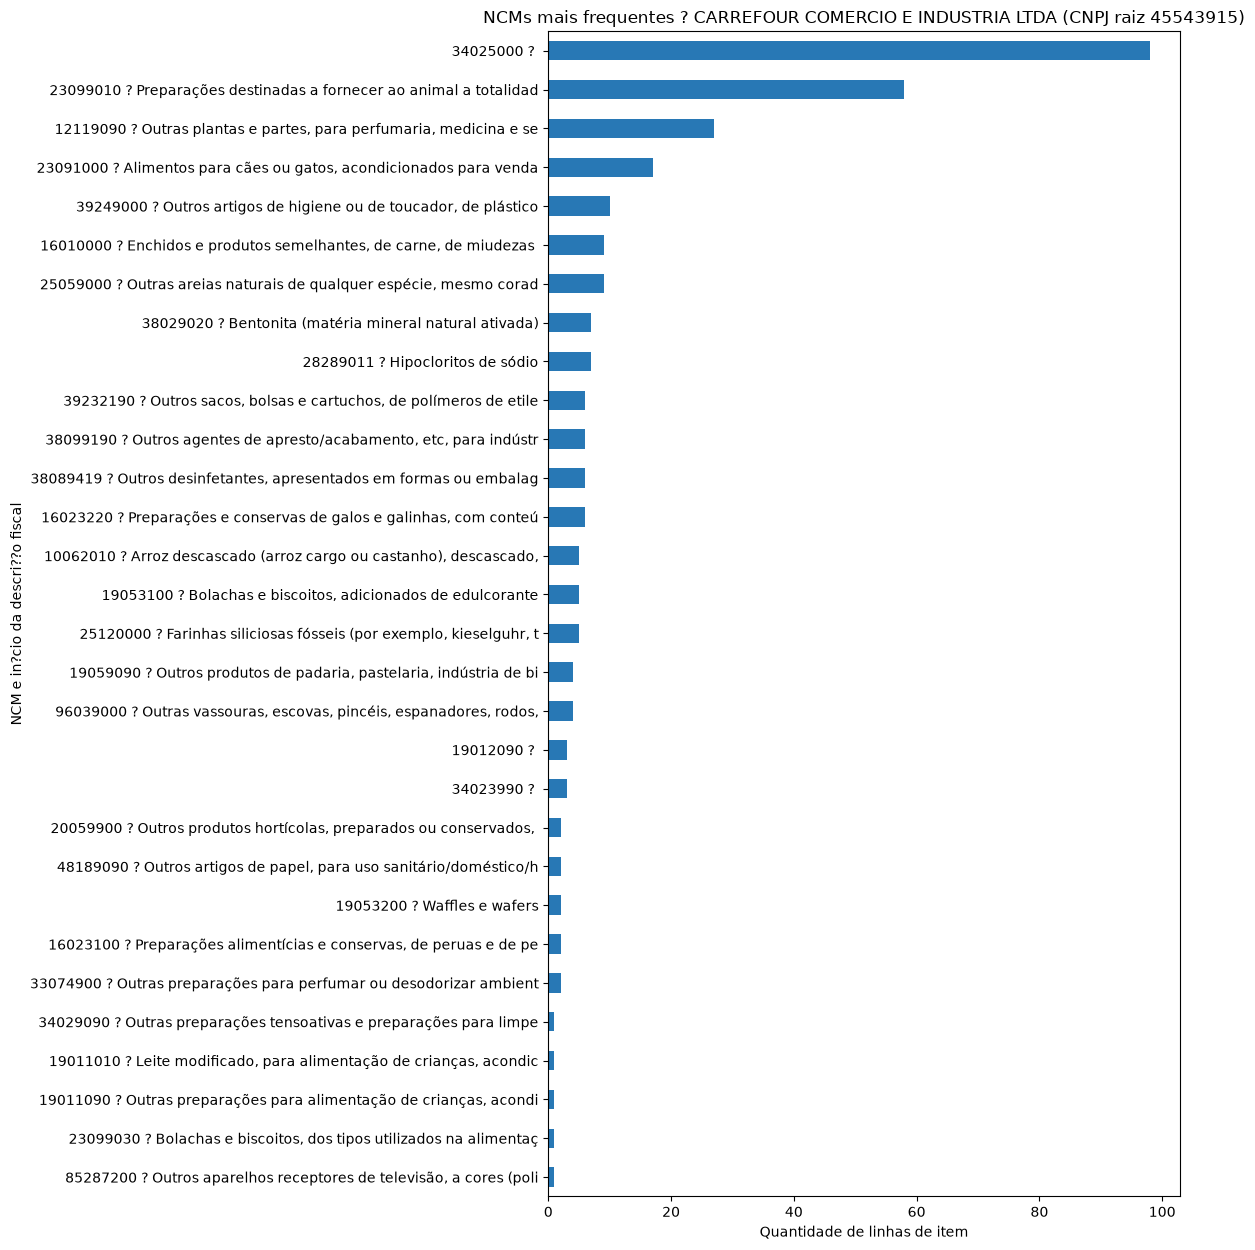

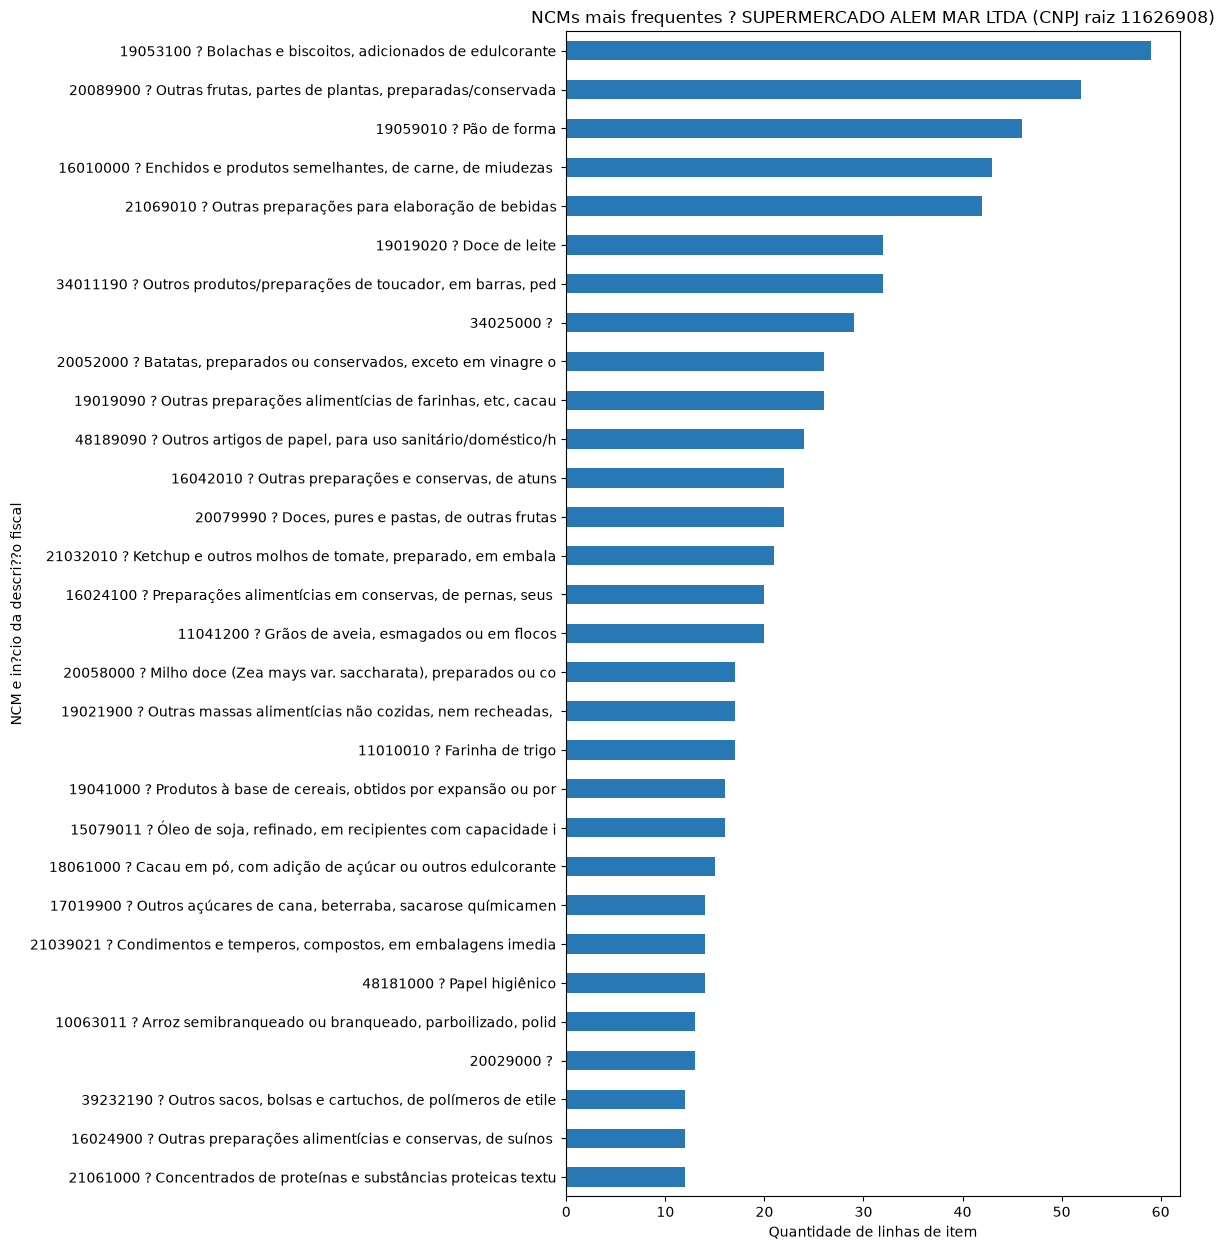

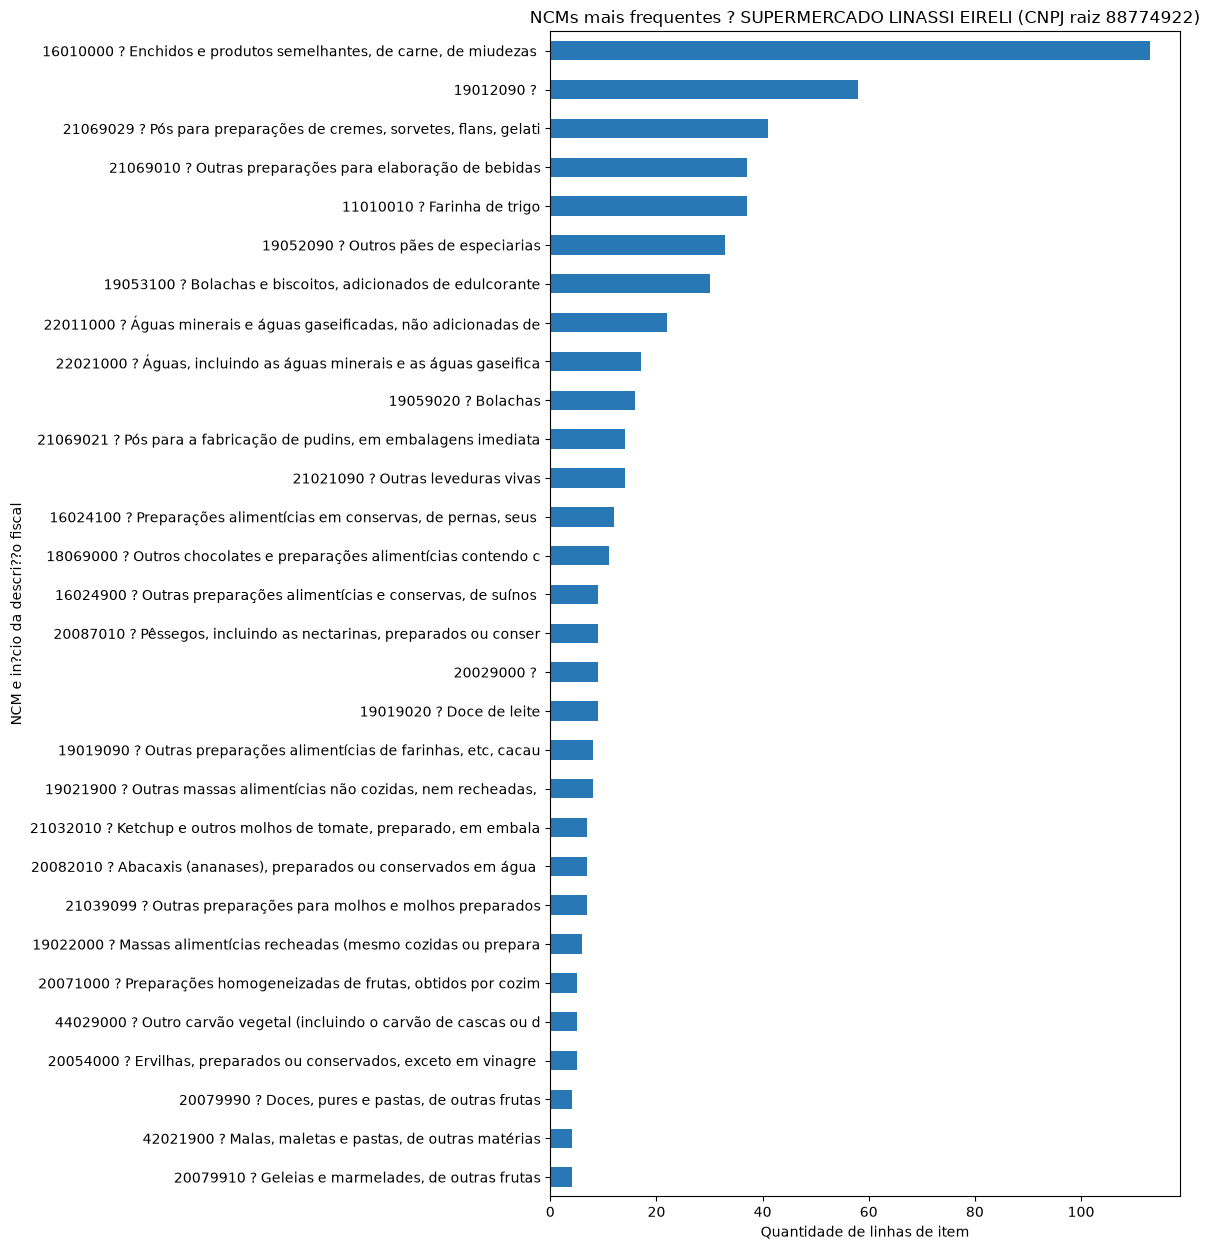

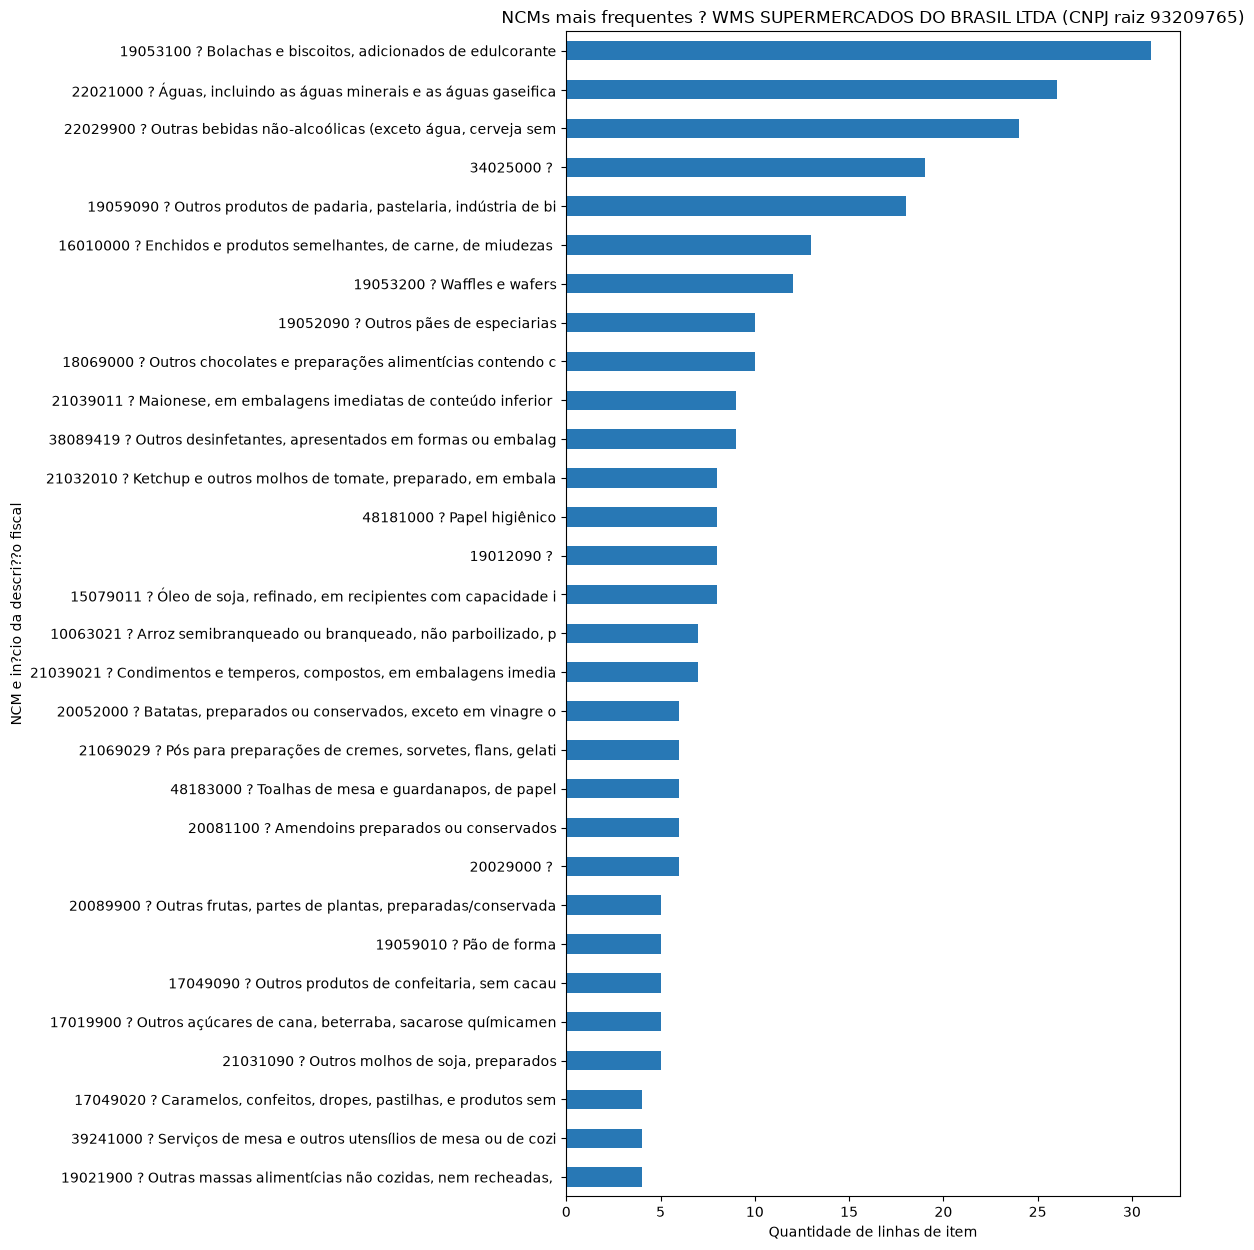

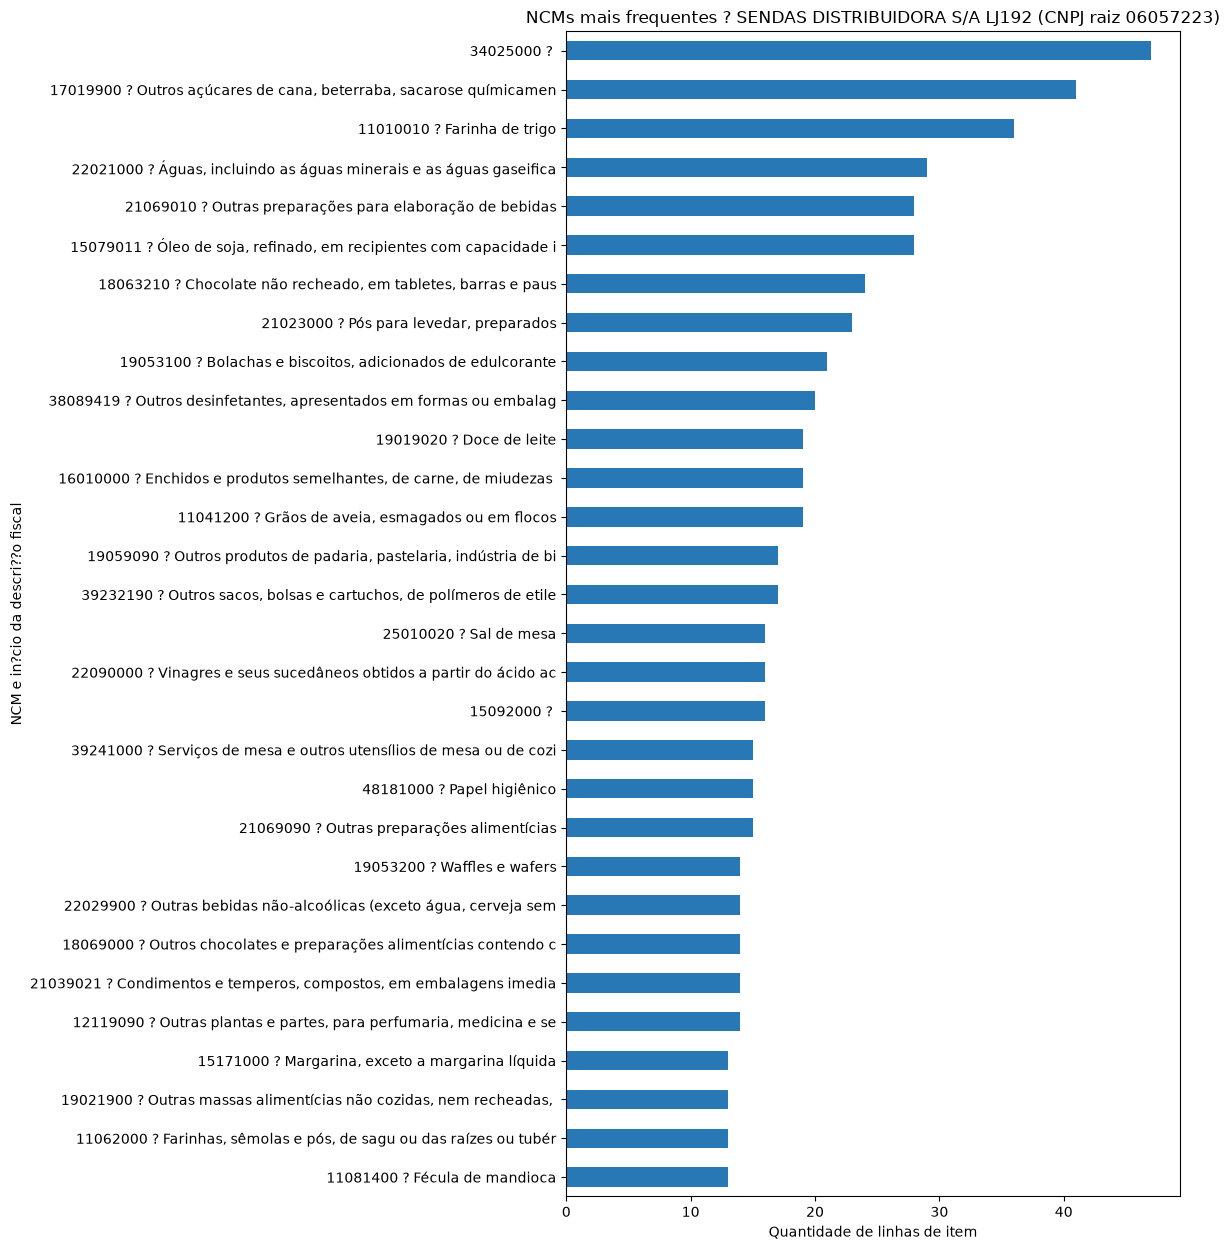

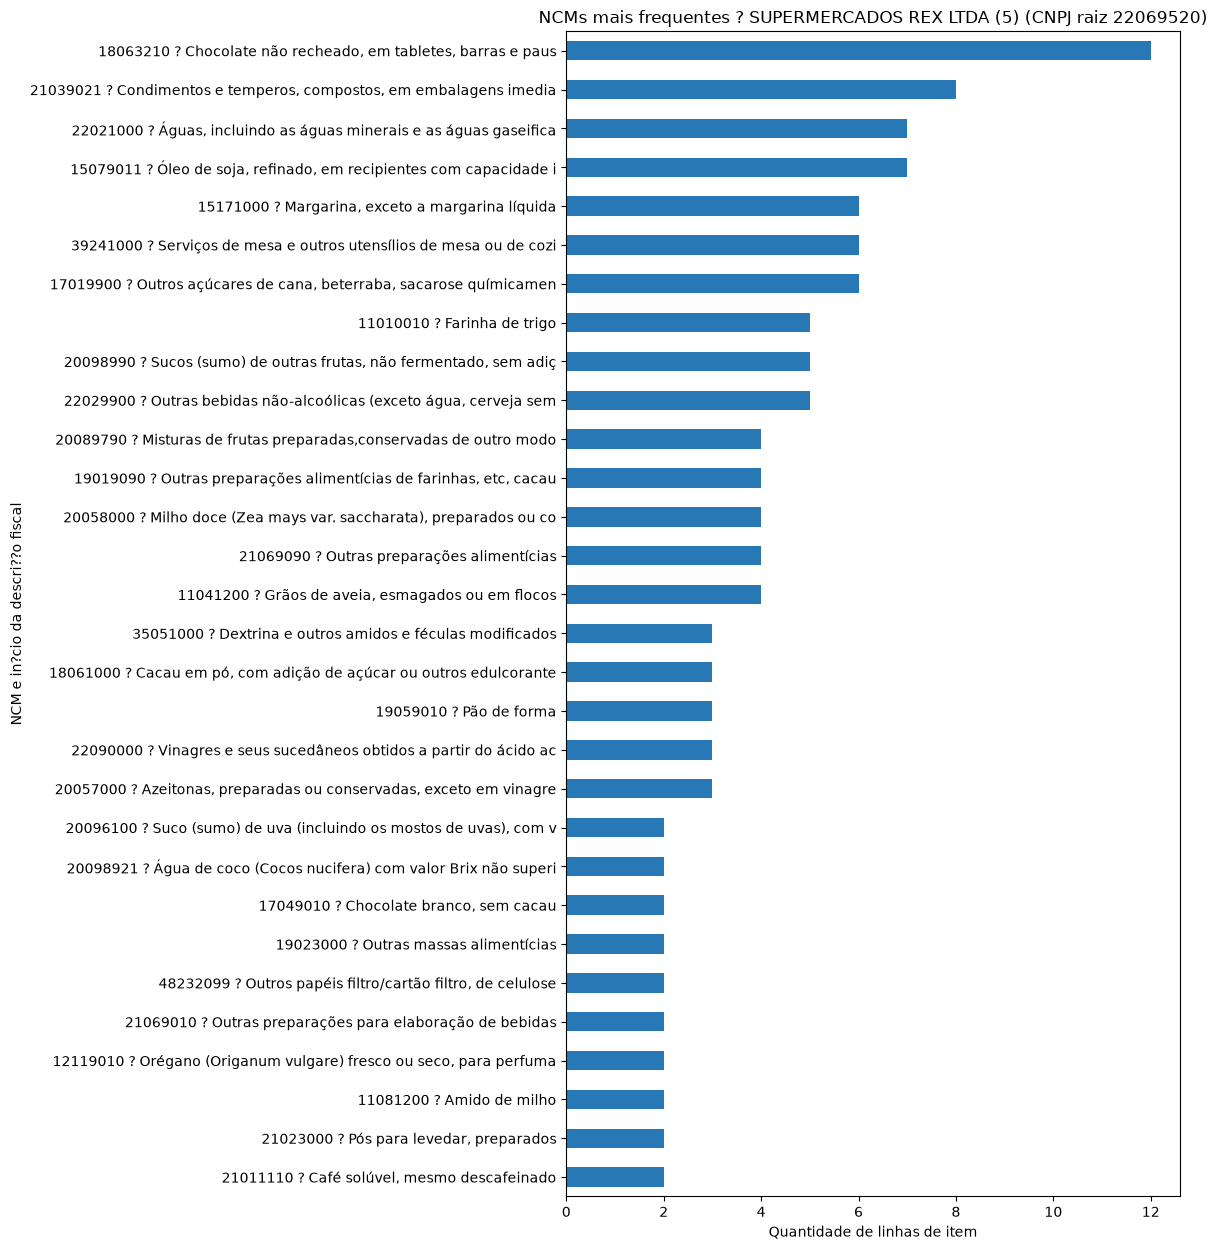

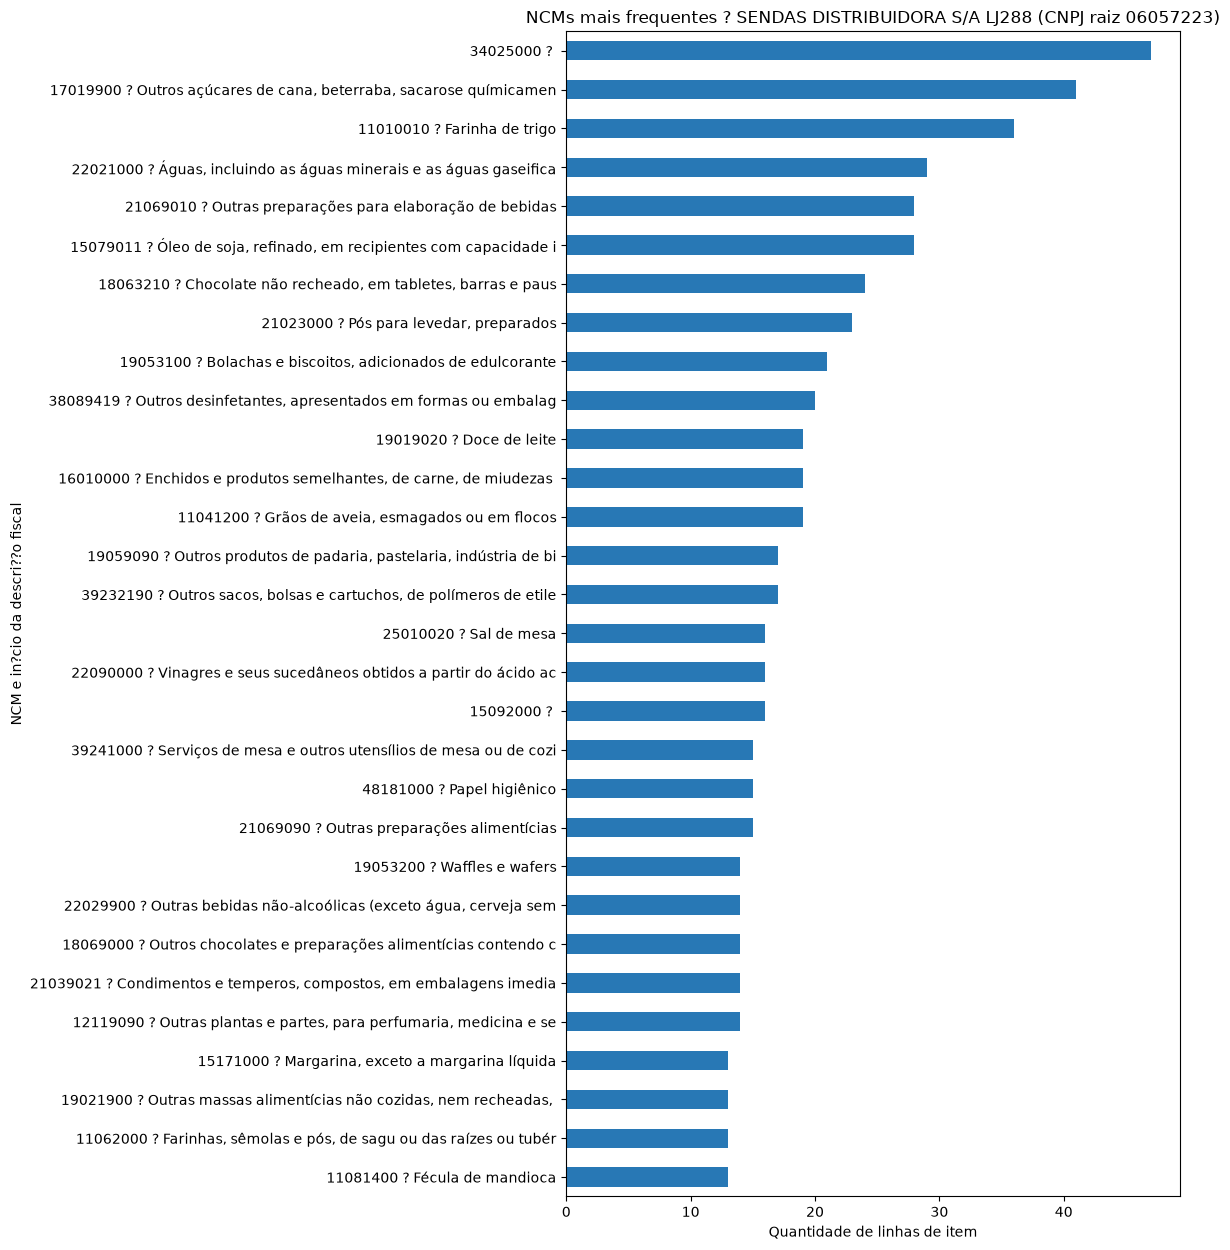

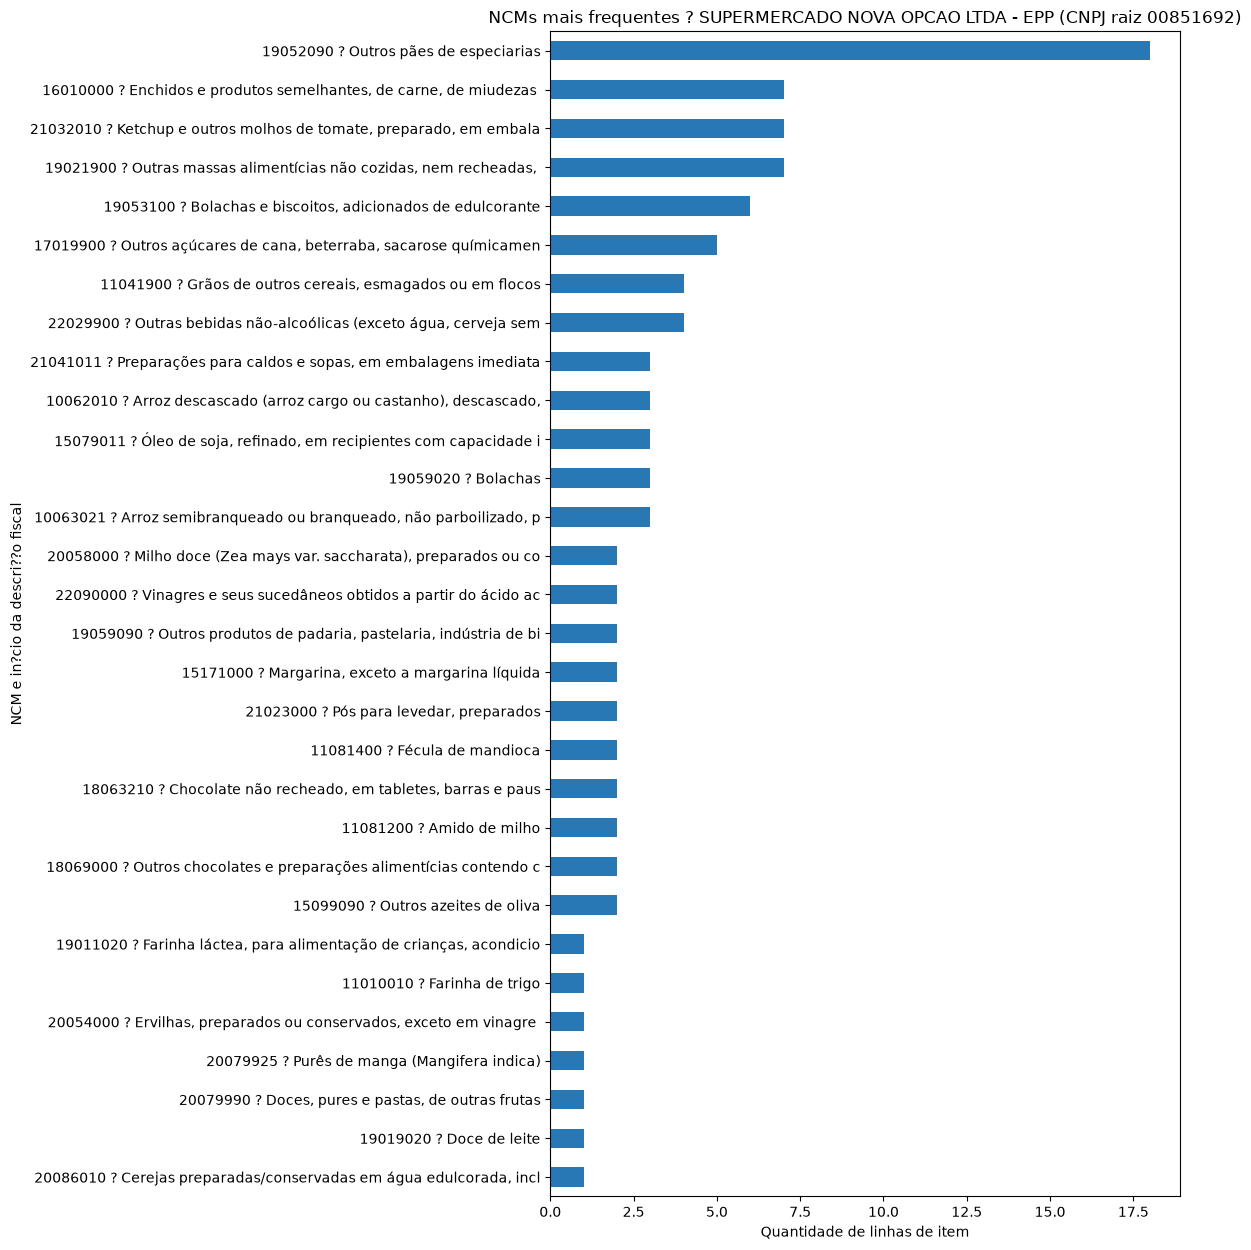

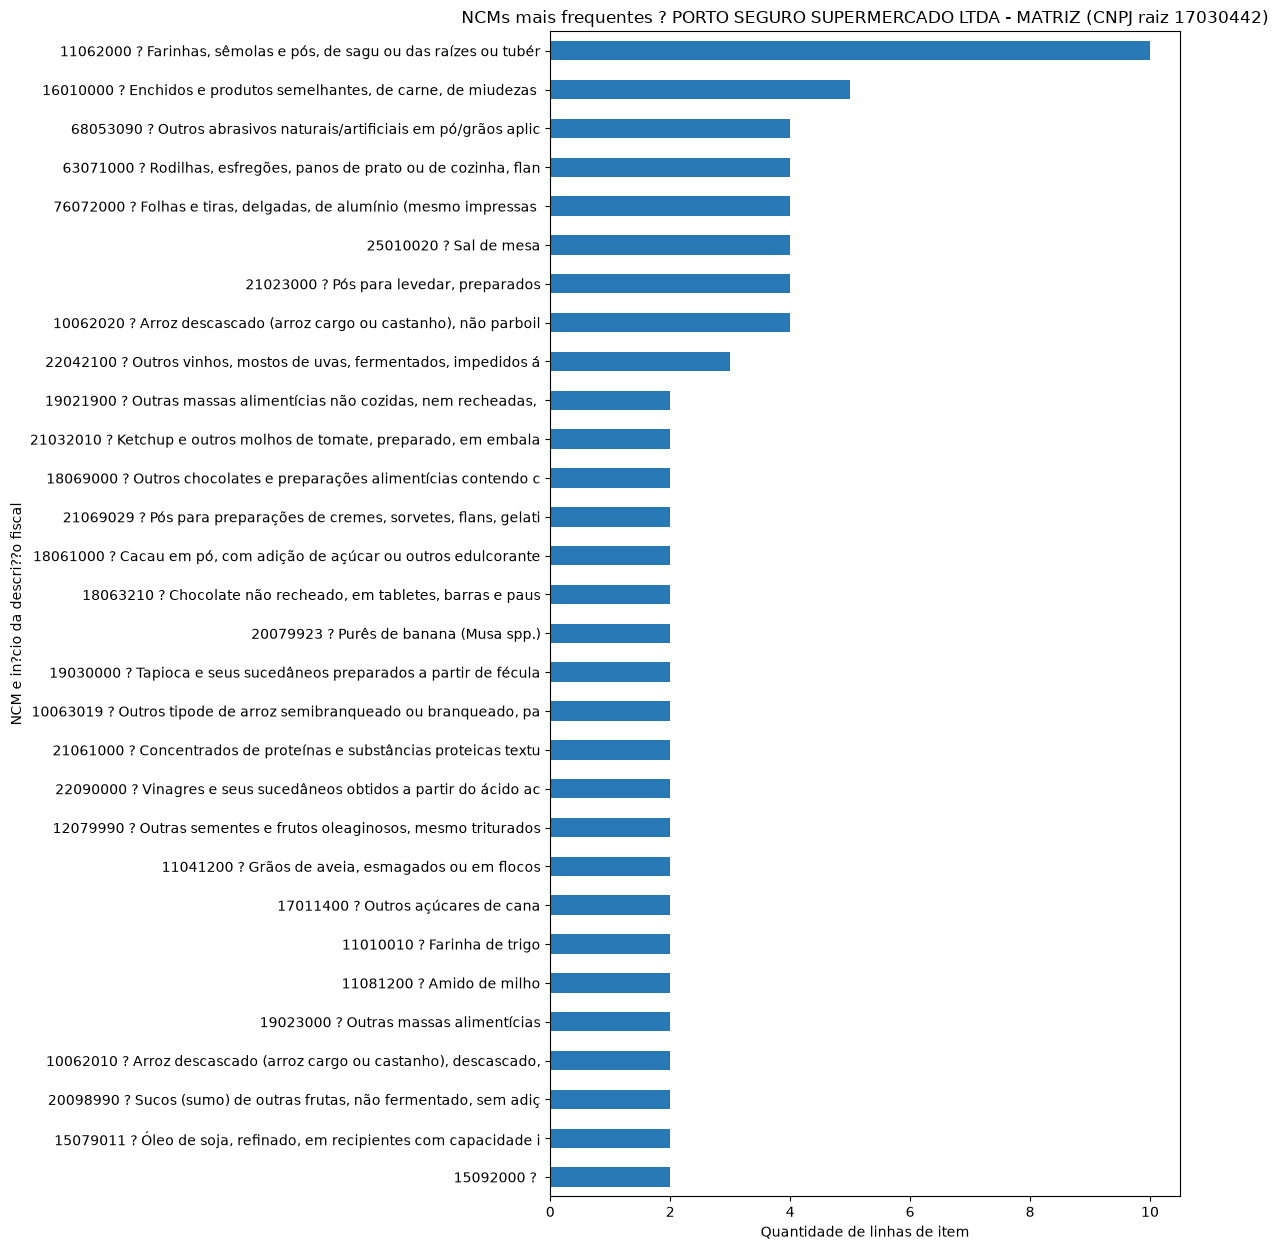

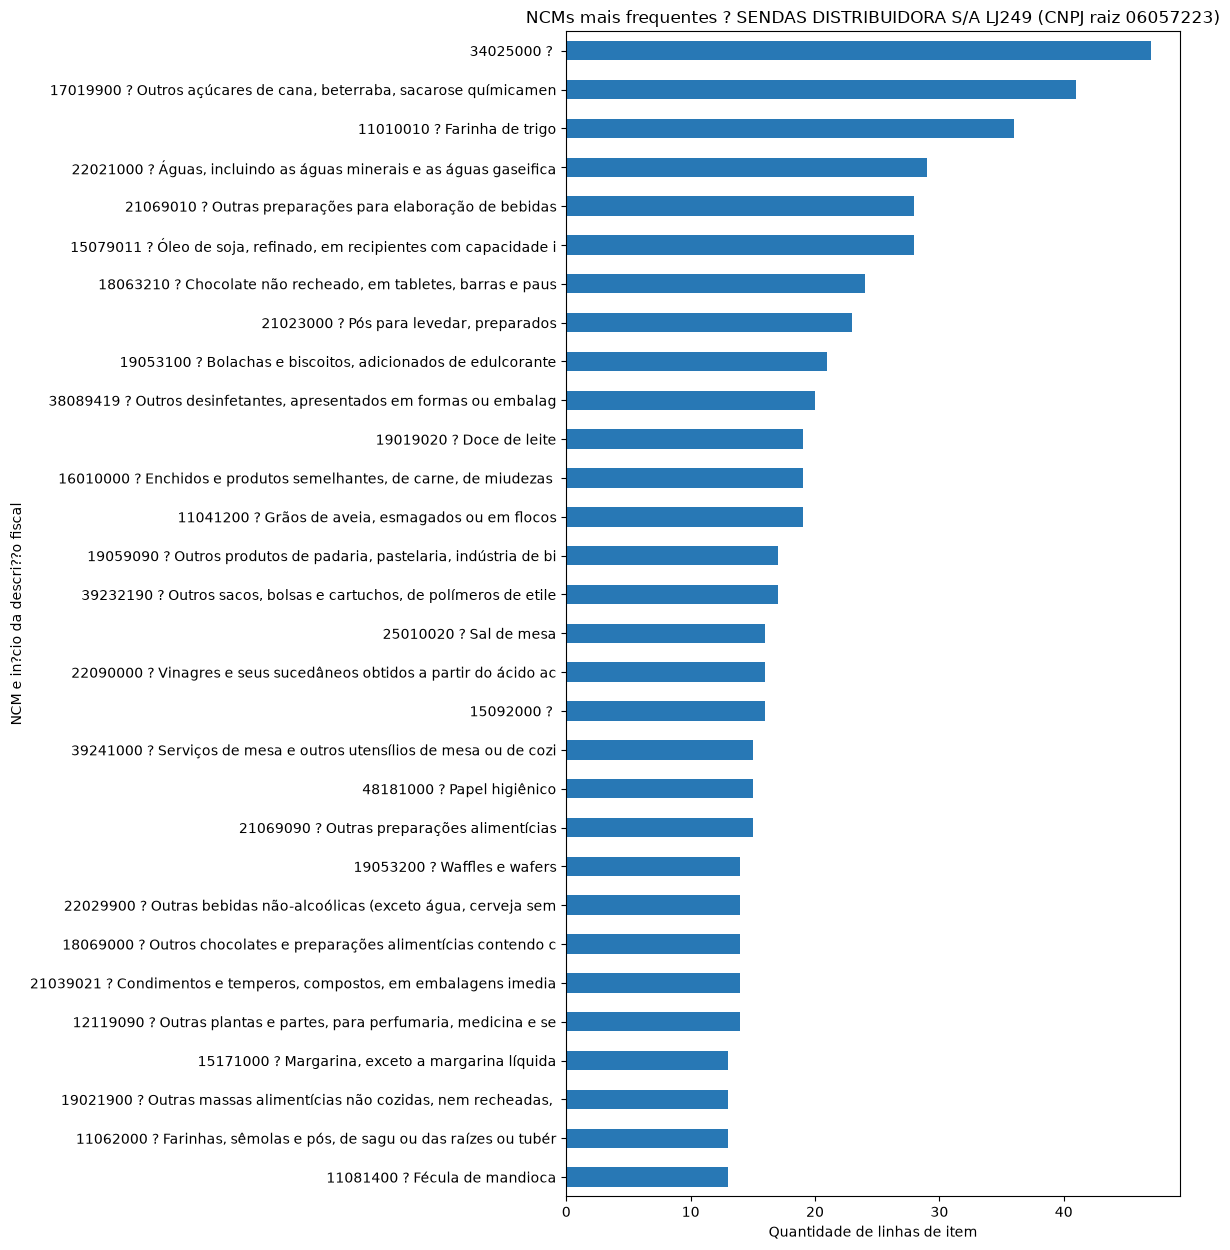

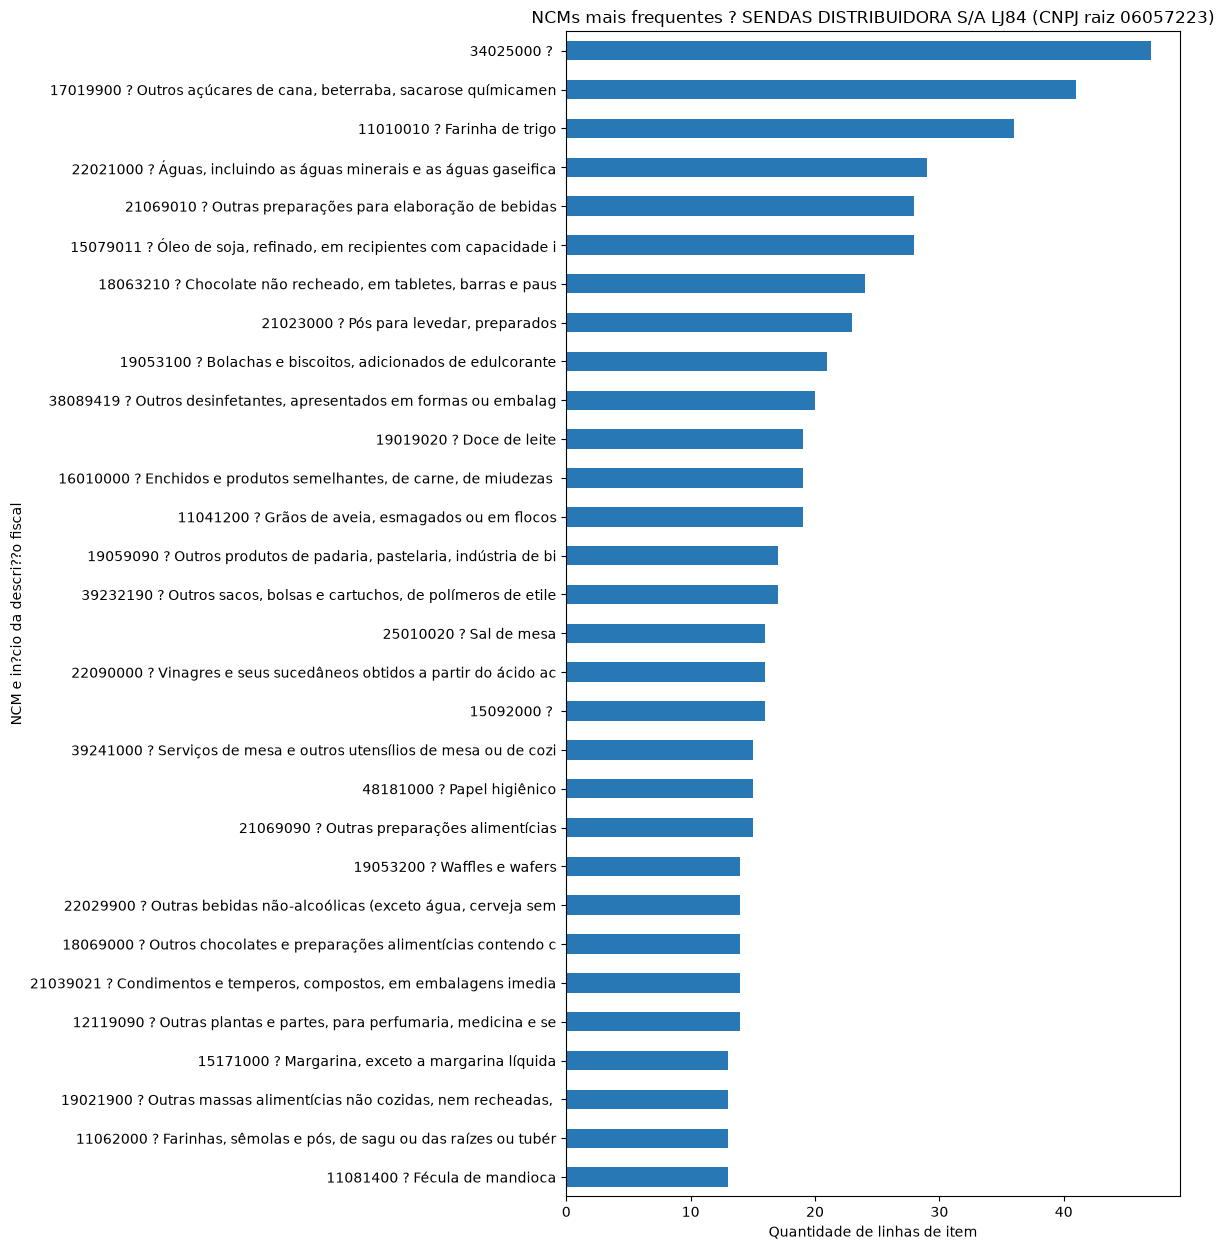

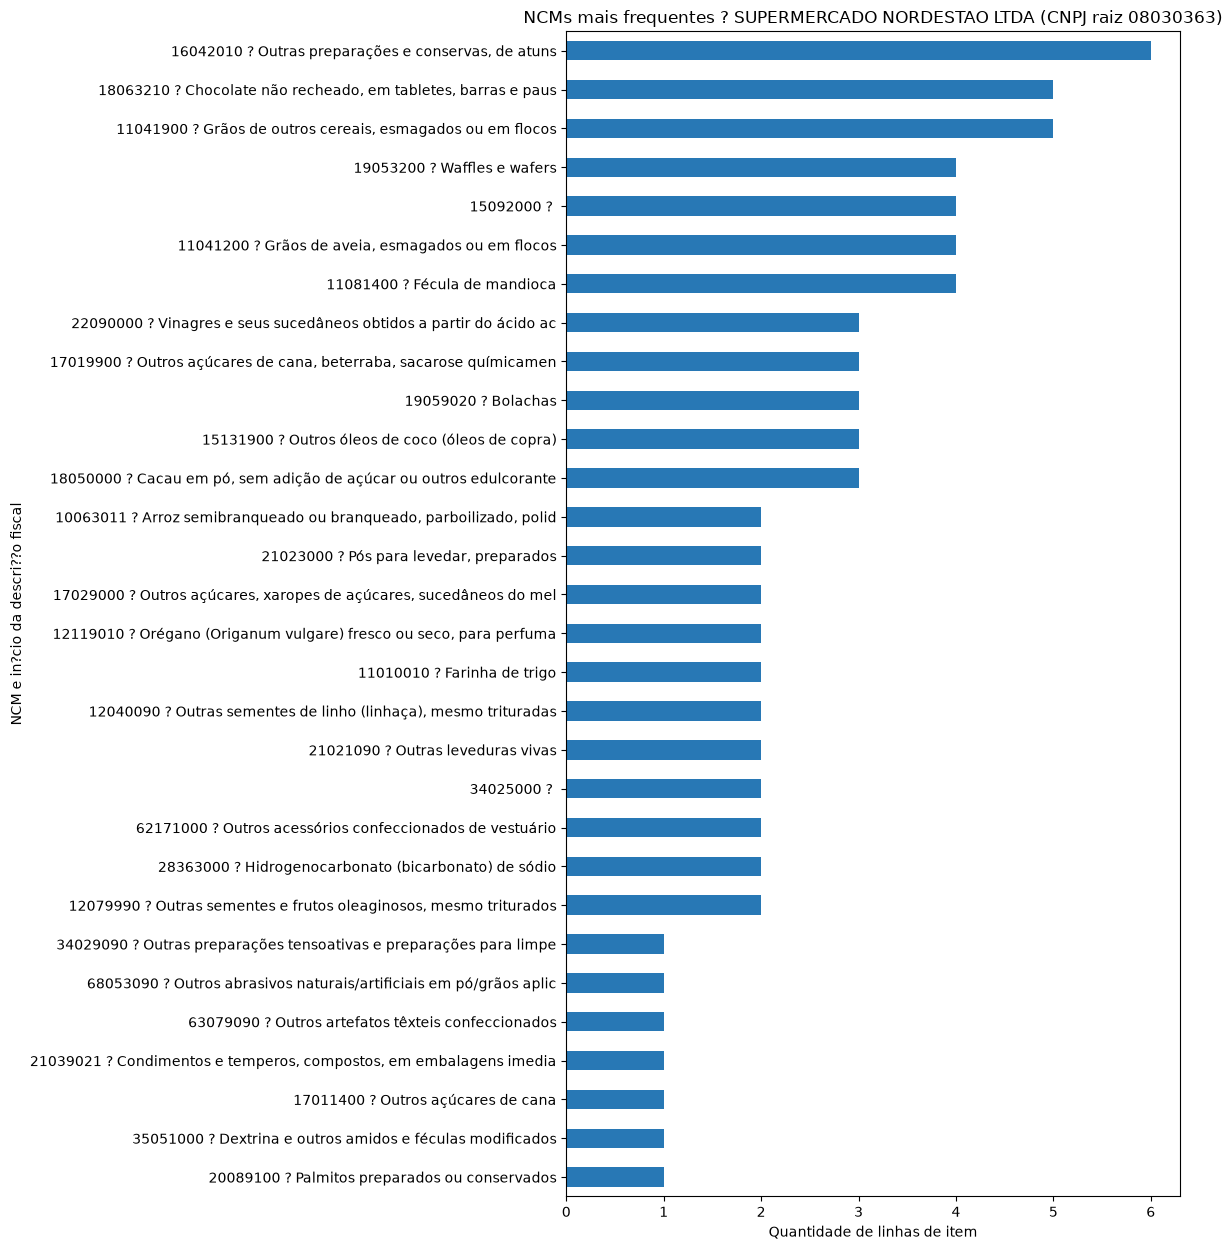

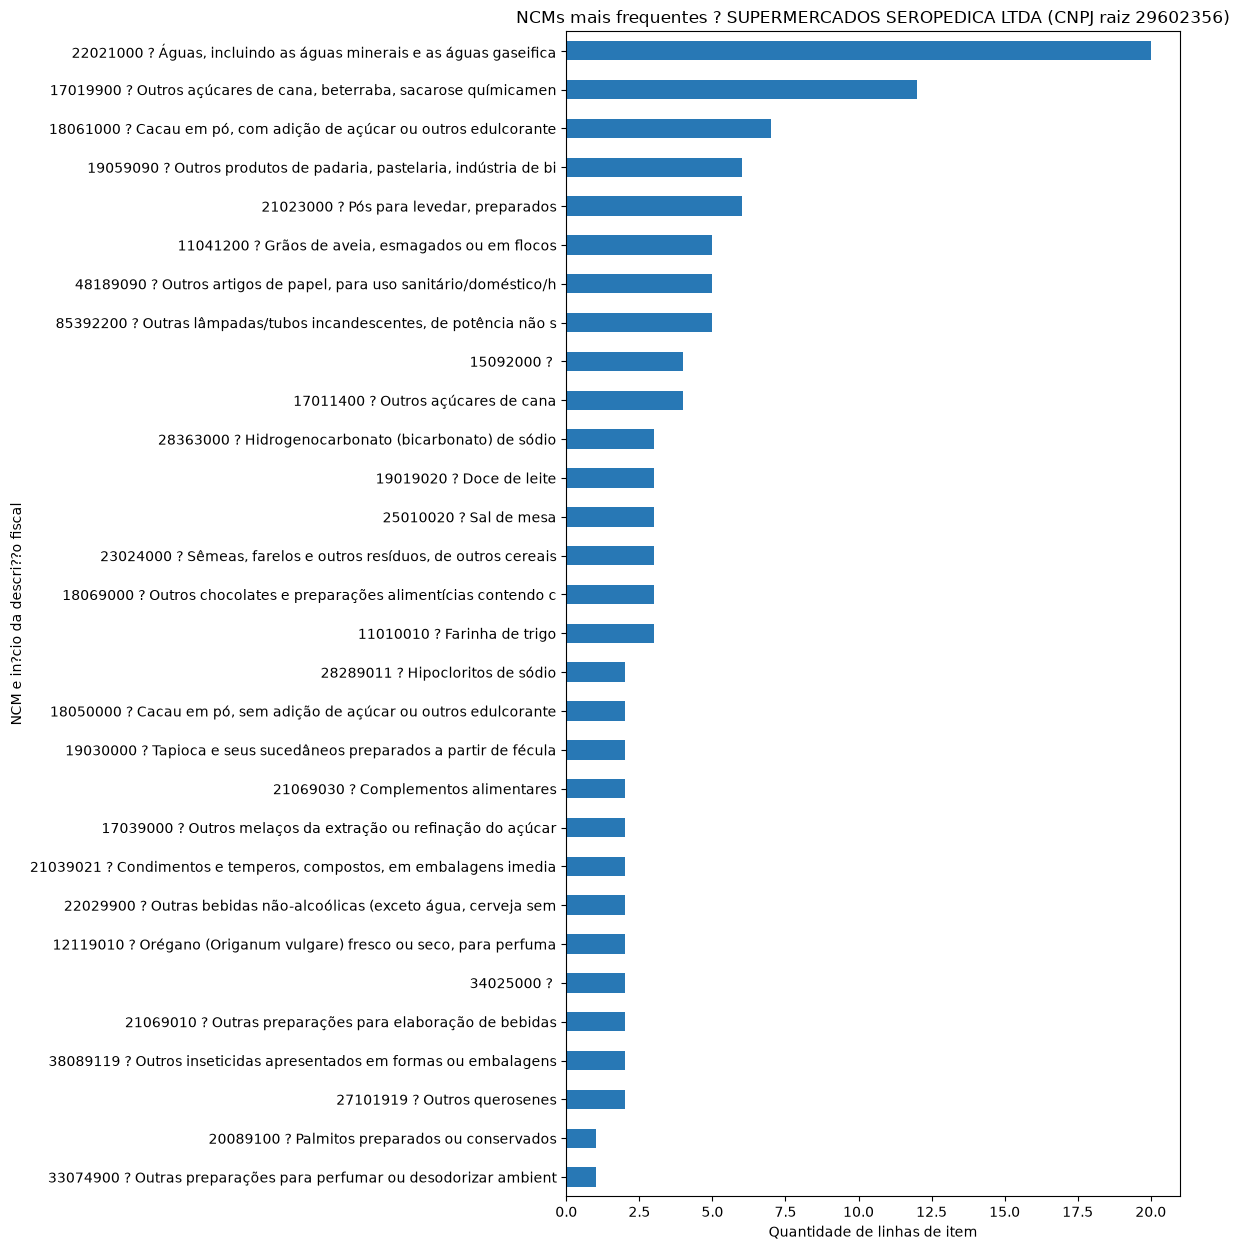

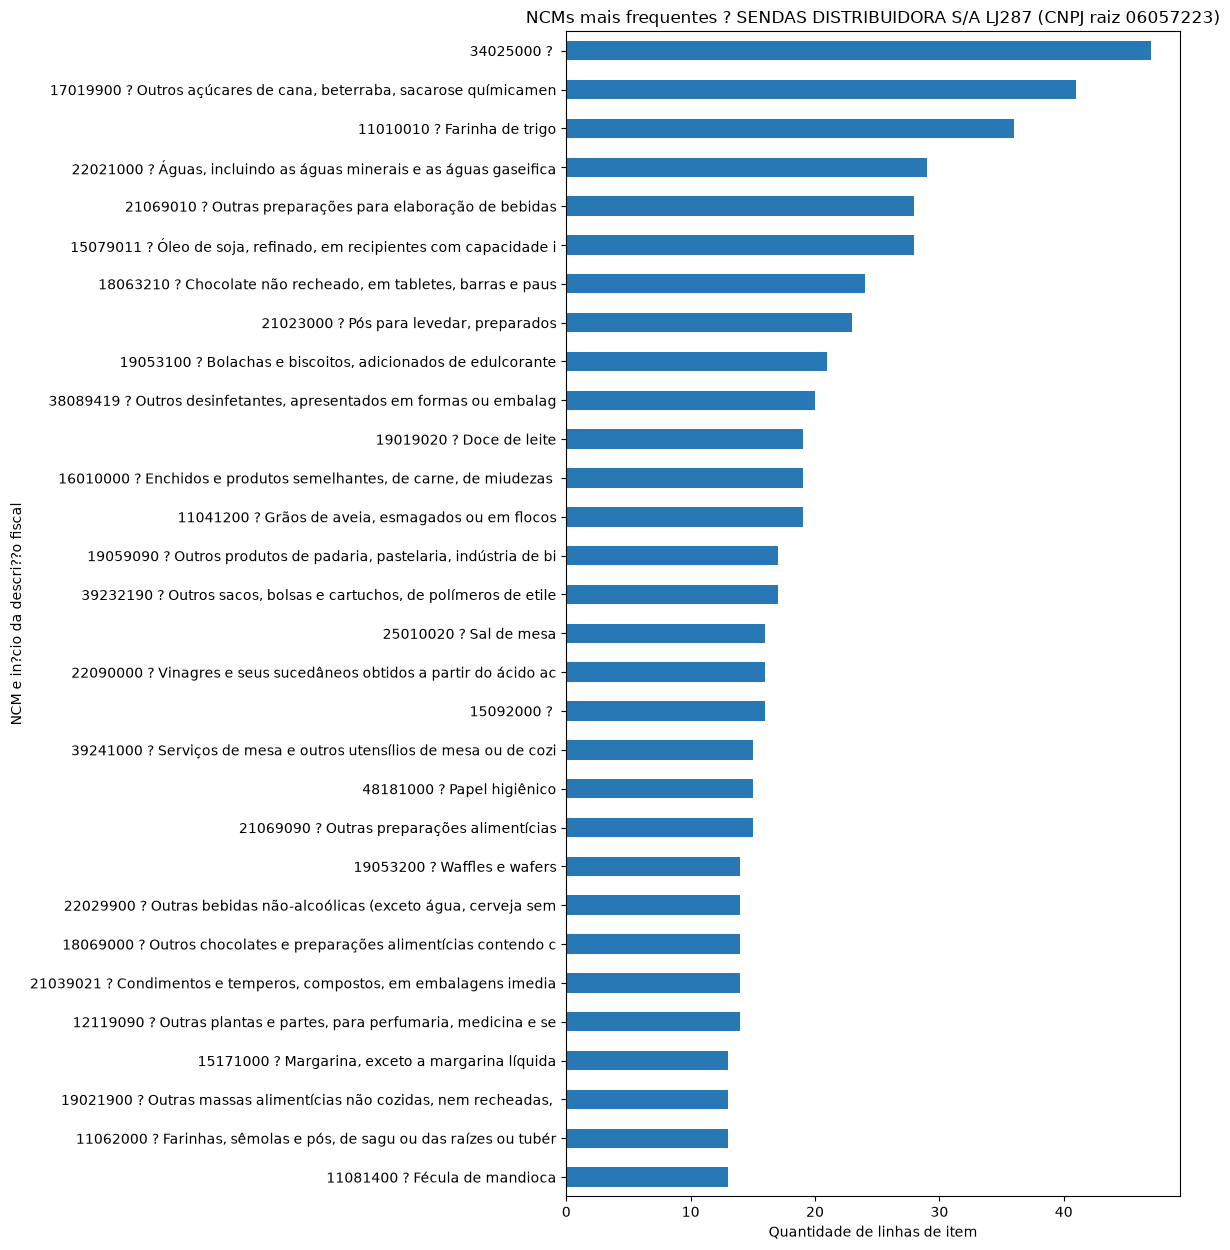

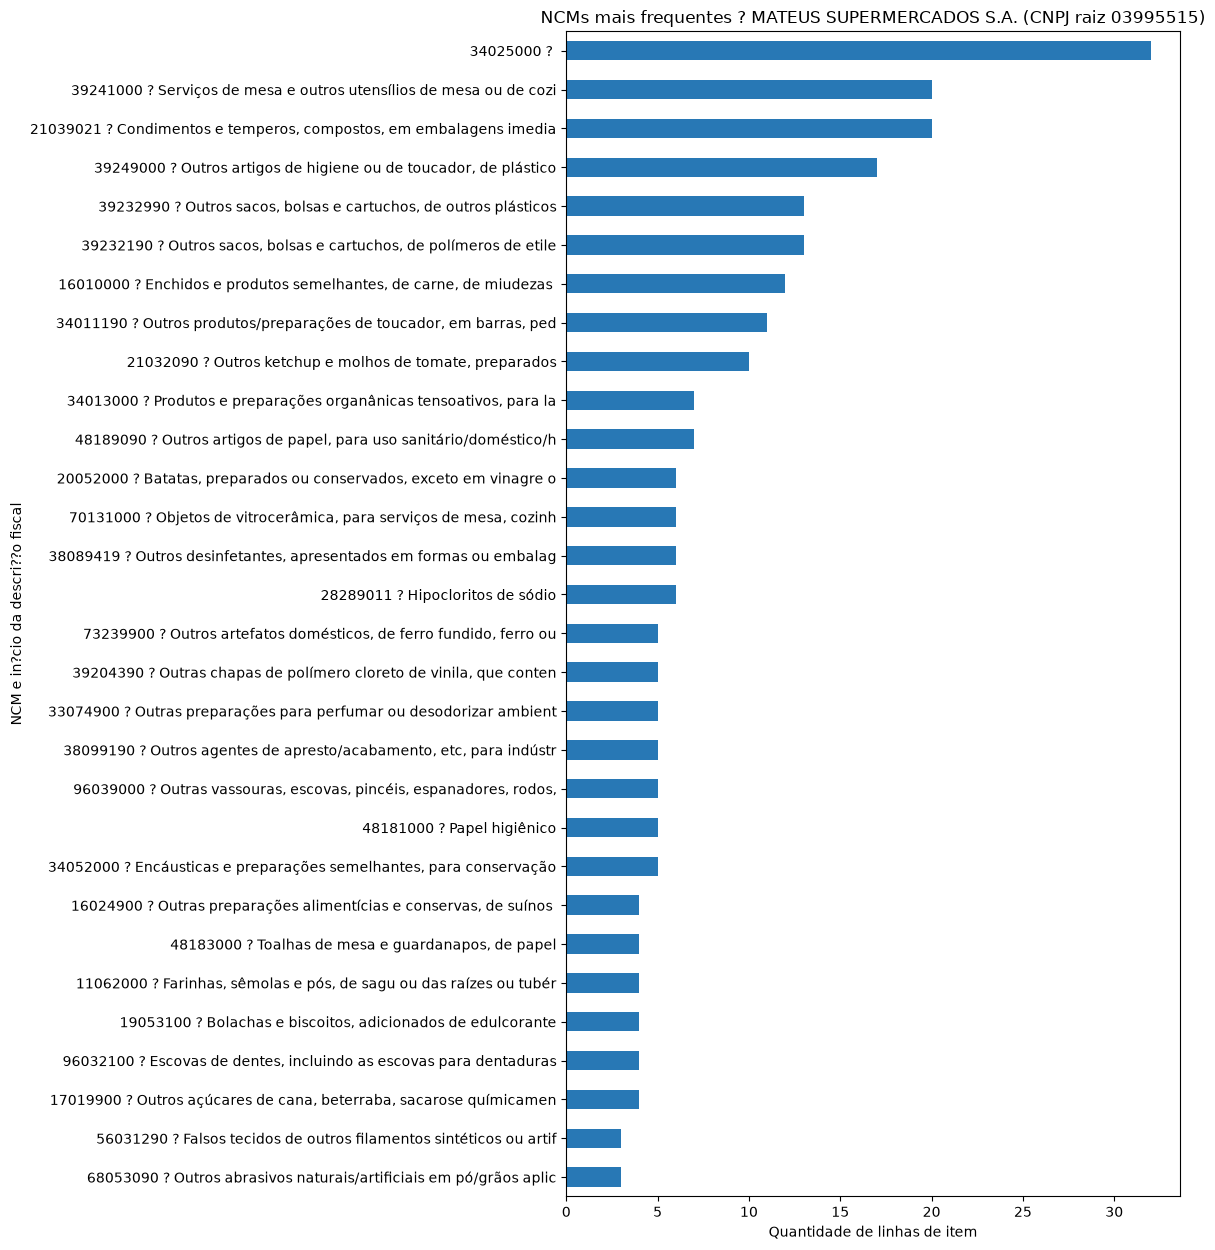

NCMs distintos: 297; linhas de item classific?veis: 4,546


,numero_ncm,descricao_ncm,linhas_item,notas_distintas,emissores_distintos,exemplo_item,percentual_itens
202,34025000,NaN,231,78,8,DET.LIQ.LISA NEUTRO,5.08139
45,16010000,"Enchidos e produtos semelhantes, de carne, de ...",222,154,9,LINGUICA CALABRESA STO ISIDORO KG,4.883414
92,19053100,"Bolachas e biscoitos, adicionados de edulcorante",158,61,9,BOLACHA MARAGOGI SAL 300G MASSARELLE 300G,3.475583
153,21069010,Outras preparações para elaboração de bebidas,115,37,7,SUCO MAGUARY 500ML GOIABA .,2.529696
8,11010010,Farinha de trigo,107,100,10,FARINHA DE TRIGO COTRIFLOR TIPO 1 5KG,2.353718
...,...,...,...,...,...,...,...
286,85279100,"Aparelhos receptores para radiodifusão, com ap...",1,1,1,CAIXA SOM AIWA TORRE AWS-T2W-02 2300W PT,0.021997
287,85287200,"Outros aparelhos receptores de televisão, a co...",1,1,1,TV 50 TOSHIBA SMART,0.021997
289,85395100,NaN,1,1,1,LAMPADA OUROLUX SUPERLED 9W SUPERLED 9W BIV,0.021997
291,95066200,Bolas infláveis,1,1,1,BOLA DE VOLEI 5 LIFESTYLE HC91169,0.021997


In [24]:
import matplotlib.pyplot as plt

# Restringe os gr?ficos aos TOP_N emissores e remove itens sem NCM v?lido.
cnpj_top = set(top_emissores["cnpj_raiz"].dropna())
itens_top_emissores = selecionados[
    selecionados["cnpj_raiz"].isin(cnpj_top)
].dropna(subset=["ncm"]).copy()

# Um gr?fico por emissor, com os NCMs mais frequentes daquele emissor.
for _, emissor in top_emissores.iterrows():
    cnpj_raiz = emissor["cnpj_raiz"]
    nome_emissor = emissor["razao_social"]
    dados_emissor = itens_top_emissores[itens_top_emissores["cnpj_raiz"] == cnpj_raiz]
    frequencias = dados_emissor["ncm"].value_counts().head(TOP_N_NCMS_POR_EMISSOR)
    if frequencias.empty:
        print(f"Sem NCM v?lido para {nome_emissor} ({cnpj_raiz}).")
        continue

    descricao_por_ncm = (
        dados_emissor.dropna(subset=[COL_DESCRICAO_NCM])
        .groupby("ncm")[COL_DESCRICAO_NCM]
        .agg(lambda valores: valores.astype(str).mode().iloc[0] if not valores.empty else "")
    )
    frequencias = frequencias.sort_values()
    rotulos = [
        f"{ncm} ? {str(descricao_por_ncm.get(ncm, '')).strip()[:55]}"
        for ncm in frequencias.index
    ]
    ax = frequencias.plot.barh(figsize=(12, max(4, 0.42 * len(frequencias))), color="#2878B5")
    ax.set_yticks(range(len(frequencias)), labels=rotulos)
    ax.set_title(f"NCMs mais frequentes ? {nome_emissor} (CNPJ raiz {cnpj_raiz})")
    ax.set_xlabel("Quantidade de linhas de item")
    ax.set_ylabel("NCM e in?cio da descri??o fiscal")
    plt.tight_layout()
    plt.show()

# Tabela completa de NCMs usados pelos TOP_N emissores, com descri??o fiscal
# informada na base e uma descri??o de item como apoio ? leitura.
ncm_completo = (
    itens_top_emissores.groupby("ncm")
    .agg(
        descricao_ncm=(COL_DESCRICAO_NCM, lambda valores: valores.dropna().astype(str).mode().iloc[0] if not valores.dropna().empty else pd.NA),
        linhas_item=("ncm", "size"),
        notas_distintas=("CHAVE DE ACESSO", "nunique"),
        emissores_distintos=("cnpj_raiz", "nunique"),
        exemplo_item=(COL_DESCRICAO, "first"),
    )
    .reset_index()
    .rename(columns={"ncm": "numero_ncm"})
    .sort_values(["linhas_item", "numero_ncm"], ascending=[False, True])
)
ncm_completo["percentual_itens"] = 100 * ncm_completo["linhas_item"] / len(itens_top_emissores)
print(f"NCMs distintos: {len(ncm_completo):,}; linhas de item classific?veis: {len(itens_top_emissores):,}")
display(ncm_completo)

In [25]:
ncm_completo.to_csv(
    RAIZ_PROJETO / "data" / "interim" / "ncms_supermercados.csv",
    index=False,
    encoding="utf-8-sig",
)

## Leitura e limita??es

- O ranking reflete os emissores e meses presentes nesta extra??o (jan?abr/2025), n?o todo o varejo brasileiro.
- A raz?o social pode n?o conter a marca da loja, e termos gen?ricos como ?mercado? ou ?atacad?o? podem capturar empresas de outros ramos. Revise a lista antes de interpretar resultados como representativos.
- Filiais podem ter CNPJs e raz?es sociais diferentes; o CNPJ raiz ? usado apenas para contar emissores distintos, n?o para inferir v?nculos societ?rios.
- A base re?ne notas autorizadas/eventos conforme o processamento do notebook 10; esta an?lise n?o deduplica eventos nem notas al?m das m?tricas explicitamente indicadas.
- NCM ausente ou fora do formato de oito d?gitos ? exclu?do somente da contagem de NCM, e seu volume ? mostrado acima.